# Track 2 — Transaction fraud detection

**Goal.** Score each transaction with a fraud probability (judged by **PR-AUC**) and a hard fraud / not-fraud decision (judged by **F1** and **Recall**).

**Answer in one paragraph.** The training data has 353 frauds in 20,000 transactions (1.77%). We benchmarked nine models with 5-fold × 3-repeat stratified cross-validation; every family (linear, spline GAM, random forest, LightGBM, XGBoost, CatBoost, EBM) lands at PR-AUC ≈ 0.21–0.23, ~12× the 0.018 no-skill baseline, so the limit is signal in the data, not model capacity. We chose an **Explainable Boosting Machine (EBM)**: it ties for the best PR-AUC, produces calibrated probabilities, is fully interpretable (every prediction is a sum of per-feature contributions), and degrades gracefully under the train→test drift we found. The decision threshold is chosen to maximise **F<sub>√3</sub>**, which is algebraically the harmonic mean of F1 and Recall — the two threshold-dependent metrics in the rubric.

The full write-up is in [`reports/MODEL_REPORT.md`](../reports/MODEL_REPORT.md); this notebook holds the evidence.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
from IPython.display import Image, display
from scipy.stats import chi2_contingency
from sklearn.metrics import average_precision_score

import fraud_pipeline as fp
import plots

pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
train, test = fp.load_data()
y = train[fp.TARGET].to_numpy()
FIG = fp.FIG_DIR
OUT = fp.OUTPUT_DIR
metrics = json.load(open(OUT / "metrics.json"))
print(f"train {train.shape}  test {test.shape}")
print(f"fraud: {y.sum()} of {len(y)} = {y.mean():.3%}  (≈ 1 in {round(1 / y.mean())})")

train (20000, 12)  test (12000, 11)
fraud: 353 of 20000 = 1.765%  (≈ 1 in 57)


## 1. Understanding the problem

* **Unit of prediction:** one card / account transaction, described by its amount, hour, merchant category, country, channel, the account's age, whether the device is new, and short-window velocity (transactions and spend in the last 1 h / 24 h).
* **Severe class imbalance (1 : 56).** A model that predicts "not fraud" for everyone is 98.2% accurate and useless, so accuracy and ROC-AUC are poor guides. **PR-AUC** (average precision) measures how well frauds are ranked above legitimate transactions *without* rewarding the huge pool of easy true negatives; its no-skill value equals the prevalence (0.018).
* **F1 and Recall need a threshold.** The model outputs a probability; the business decision (block / review) is `p ≥ t`. Recall = share of frauds caught; precision = share of alerts that are real fraud. In fraud operations a missed fraud (FN) usually costs far more than a manual review (FP), so we deliberately lean towards recall — but not so far that precision (and hence F1) collapses.
* **Test set is unlabelled and comes from a later period** (IDs 20001–32000 follow the training IDs 1–20000). We therefore estimate performance with cross-validation and check explicitly how different the test distribution is.

In [2]:
display(train.head())
summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_train_%": train.isna().mean() * 100,
    "missing_test_%": test.isna().mean().reindex(train.columns) * 100,
    "n_unique": train.nunique(),
})
summary

,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud
0,FR016993,55.03,16,retail,SG,ecommerce,27.0,1791.34,1192.0,0.0,5.0,0
1,FR002433,20.75,1,gaming,SG,mobile_app,3.0,217.96,3073.0,0.0,0.0,0
2,FR009253,21.51,9,entertainment,SG,mobile_app,3.0,62.71,985.0,0.0,0.0,0
3,FR004881,813.98,16,utilities,GB,mobile_app,2.0,110.48,653.0,0.0,1.0,0
4,FR014830,13.54,20,food_delivery,SG,card_present,4.0,114.98,79.0,0.0,0.0,0


,dtype,missing_train_%,missing_test_%,n_unique
id,str,0.000,0.0000,20000
transaction_amount,float64,0.000,0.0000,14134
transaction_hour,int64,0.000,0.0000,24
merchant_category,str,0.565,2.1583,11
country,str,0.535,2.2333,10
transaction_channel,str,0.615,2.3667,4
transactions_last_24h,float64,0.795,2.4417,27
spend_last_24h,float64,0.660,2.2250,16987
account_age,float64,0.685,2.2000,3366
new_device,float64,0.620,2.4417,2


## 2. What drives fraud? (exploratory analysis)

Fraud rate by binned feature value. The horizontal line is the overall 1.77% rate.

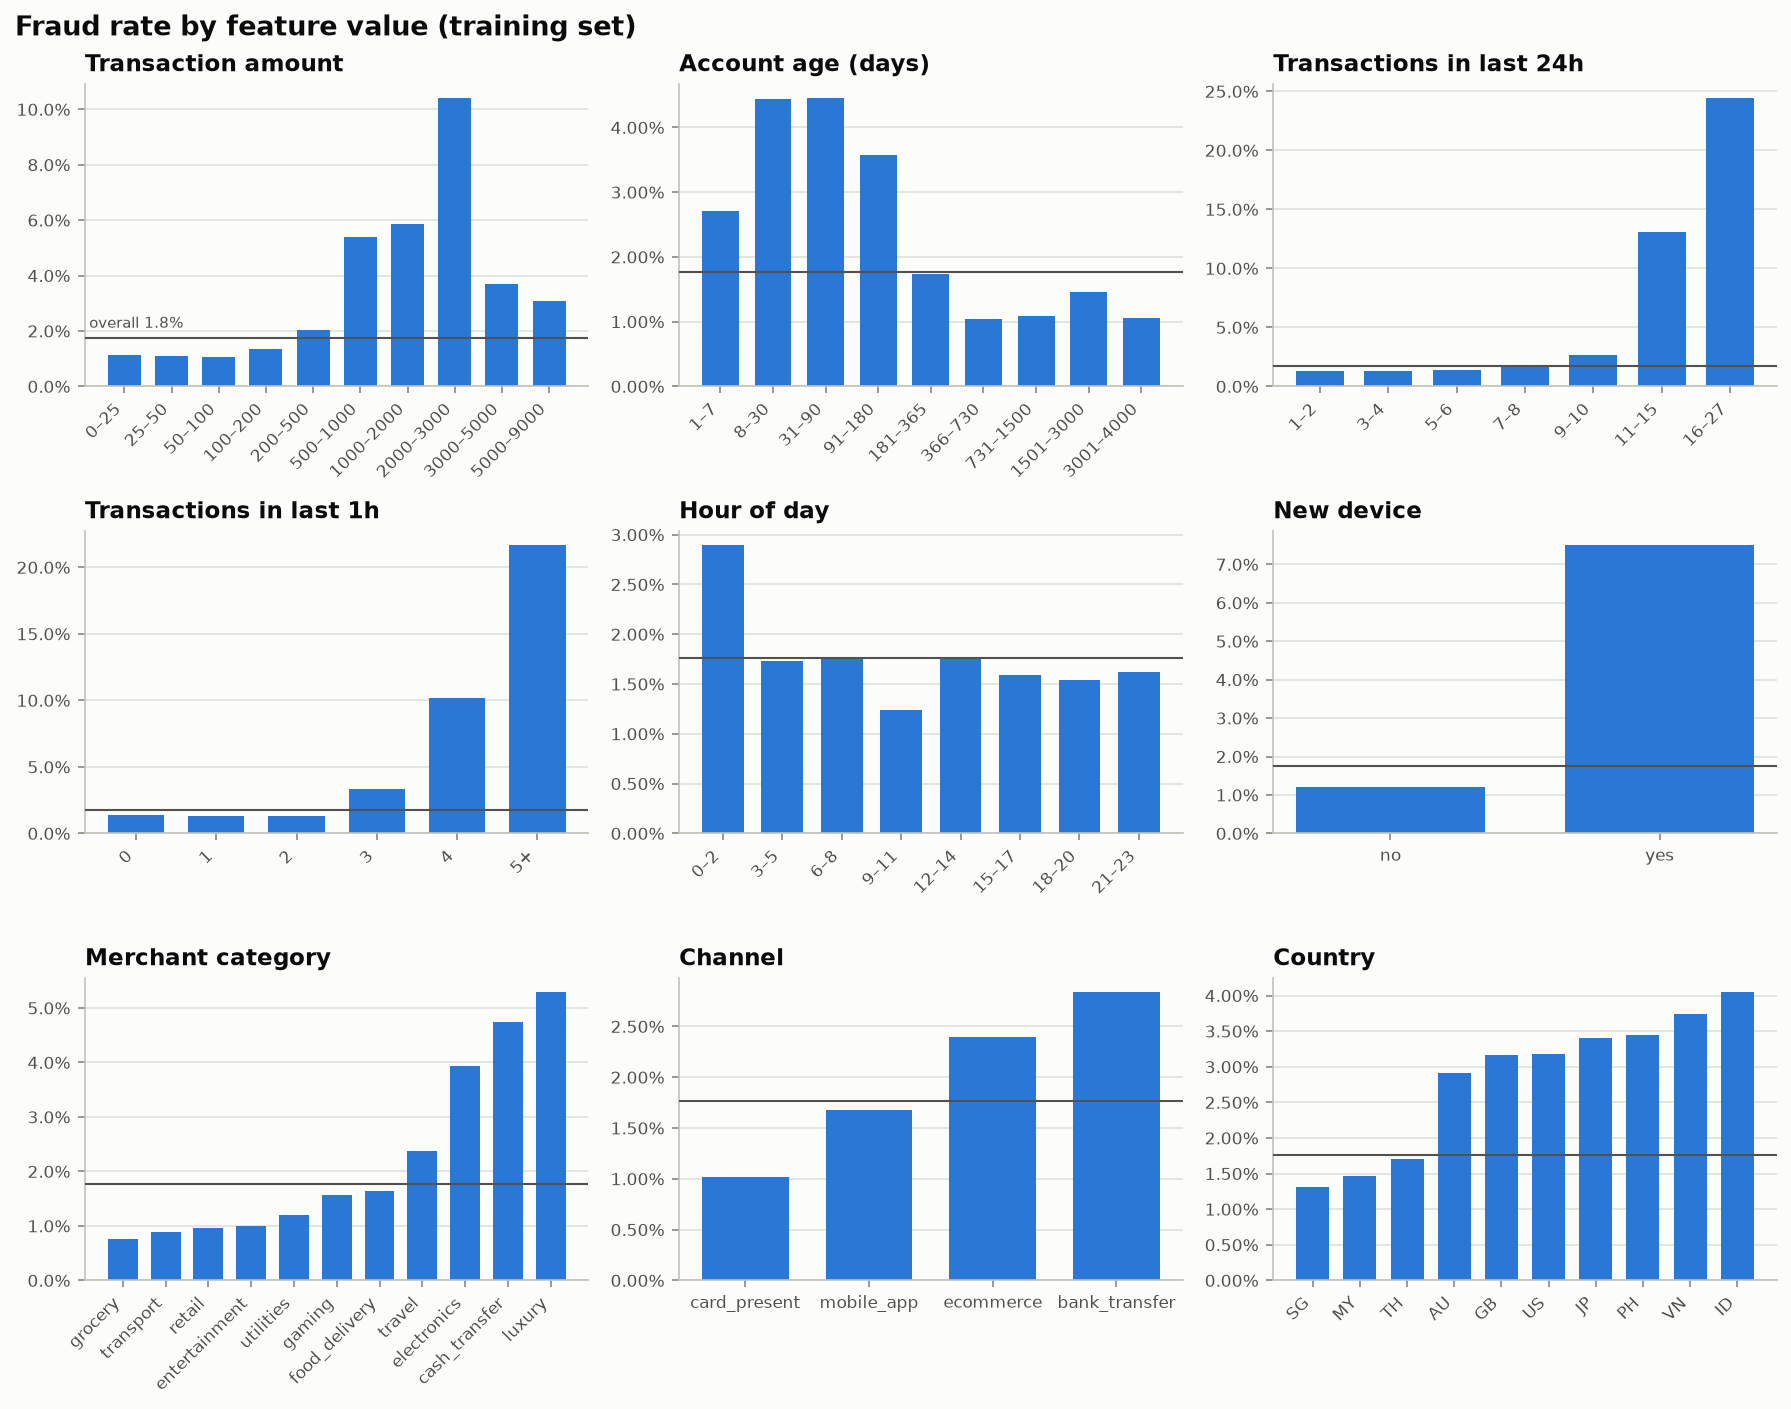

In [3]:
plots.fig_risk_drivers(train, FIG / "01_risk_drivers.png")
display(Image(FIG / "01_risk_drivers.png"))

**Reading the chart**

| Signal | Pattern | Fraud intuition |
|---|---|---|
| Velocity (`transactions_last_24h`, `transactions_last_1h`) | flat until ~10/day or ≥3/hour, then 13–25% fraud | card-testing / account drain bursts |
| `new_device` | 7.5% vs 1.2% | account takeover from an unfamiliar device |
| `account_age` | 8–180 days ≈ 4.5%, > 1 year ≈ 1% | mule / freshly opened accounts |
| `transaction_amount` | rises from ~$500, peaks at $2–3k | cash-out, but very large tickets are rarer |
| Merchant / channel | cash transfer, luxury, electronics; bank transfer & e-commerce | easily resold goods, card-not-present |
| Hour | higher 23:00–04:00 | victims asleep, fewer real customers |
| Country | non-SG ≈ 2–2.5× SG | cross-border risk |

The effects are **non-linear and step-like** (thresholds on velocity, a hump in account age), which rules out a plain linear model on raw values and motivates models that learn shape functions.

In [4]:
# The interaction we expected from domain knowledge: new device on a young account
pd.crosstab(train.new_device.map({0: "known device", 1: "new device"}),
            np.where(train.account_age < 30, "account < 30 days", "account ≥ 30 days"),
            values=train.fraud, aggfunc="mean").style.format("{:.1%}")

col_0,account < 30 days,account ≥ 30 days
new_device,,
known device,1.1%,1.2%
new device,25.3%,6.5%


### Data quality

* Every non-ID column has a little missingness (0.5–0.8% in train, 2–2.4% in test). Missing rows are not materially more fraudulent (χ² tests below), consistent with *missing completely at random*. The EBM puts missing values in their own bin, so no imputation is needed.
* `account_age` is capped at 4000 days and `transaction_amount` at 9000 (spikes at the maximum).
* `spend_last_24h` is below the current amount in ~20% of rows, so it excludes the current transaction — the velocity features look backwards only (no leakage).

In [5]:
rows = []
for c in fp.RAW_FEATURES:
    m = train[c].isna()
    if m.sum():
        chi2, pval, *_ = chi2_contingency(pd.crosstab(m, train.fraud))
        rows.append({"feature": c, "n_missing": int(m.sum()), "fraud_rate_if_missing": train.fraud[m].mean(),
                     "fraud_rate_if_present": train.fraud[~m].mean(), "chi2_p_value": pval})
pd.DataFrame(rows)

,feature,n_missing,fraud_rate_if_missing,fraud_rate_if_present,chi2_p_value
0,transactions_last_24h,159,0.0314,0.0175,0.3058
1,spend_last_24h,132,0.0303,0.0176,0.4377
2,account_age,137,0.0219,0.0176,0.9574
3,new_device,124,0.0000,0.0178,0.2480
4,transactions_last_1h,142,0.0282,0.0176,0.5251
5,merchant_category,113,0.0000,0.0178,0.2843
6,country,107,0.0093,0.0177,0.7749
7,transaction_channel,123,0.0325,0.0176,0.3613


## 3. Is the test set like the training set? (adversarial validation)

We train a classifier to distinguish training rows from test rows. AUC = 0.5 would mean identical distributions.

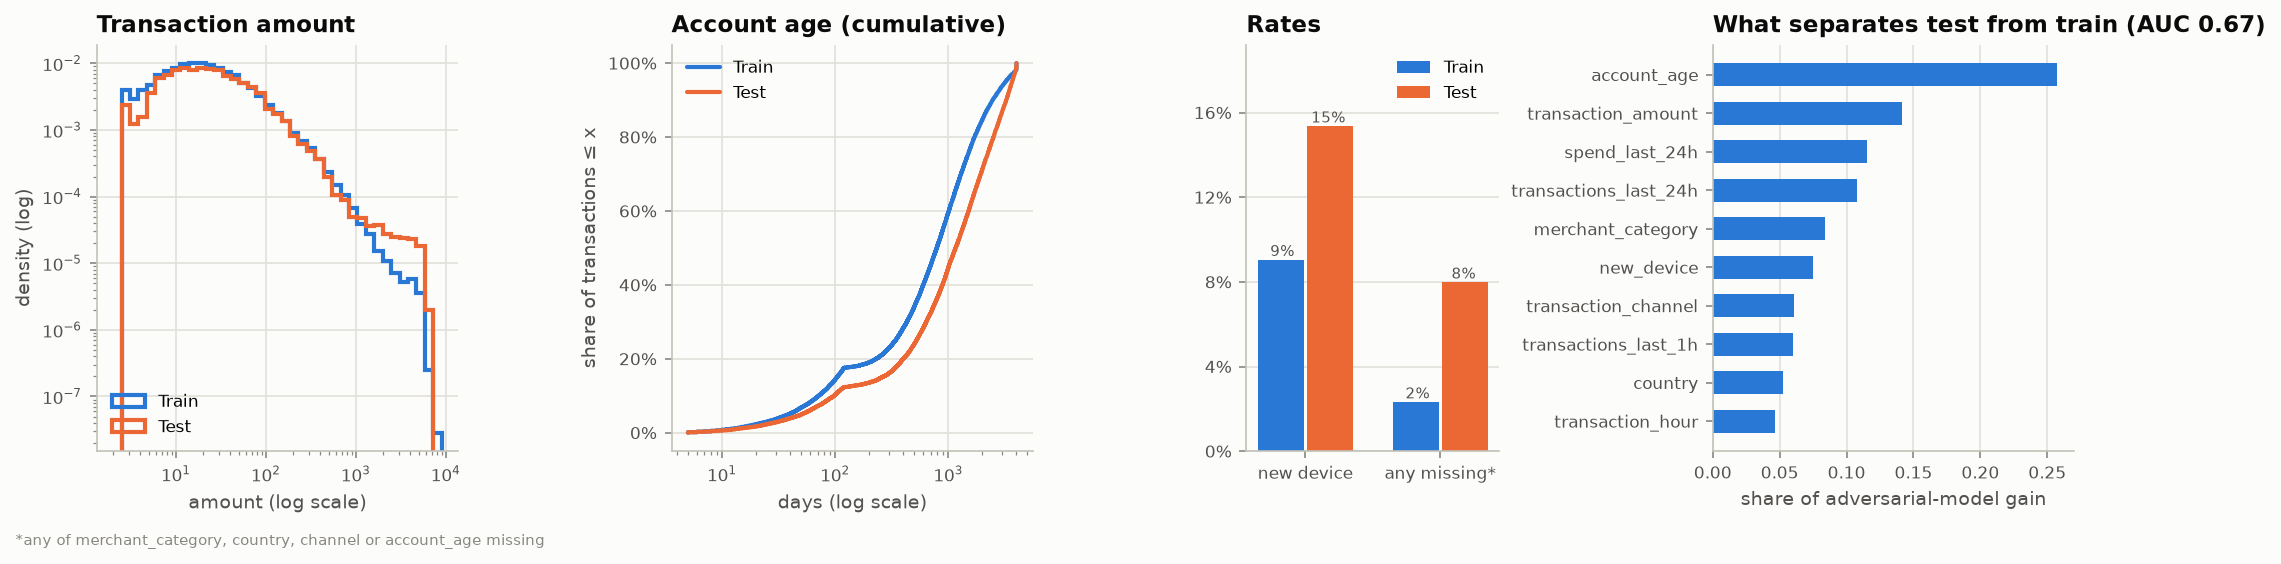

adversarial AUC = 0.670


In [6]:
adv_auc, adv_imp, iw = fp.adversarial_validation(train, test)
plots.fig_drift(train, test, adv_auc, adv_imp, FIG / "02_drift.png")
display(Image(FIG / "02_drift.png"))
print(f"adversarial AUC = {adv_auc:.3f}")

In [7]:
def profile(d):
    return pd.Series({
        "rows": len(d), "new_device": d.new_device.mean(), "median_account_age": d.account_age.median(),
        "account_age<=180d": (d.account_age <= 180).mean(), "24h_txns>=10": (d.transactions_last_24h >= 10).mean(),
        "night (23-04h)": d.transaction_hour.isin([23, 0, 1, 2, 3, 4]).mean(), "country=SG": (d.country == "SG").mean(),
    })
big_tr, big_te = train.transaction_amount > 1000, test.transaction_amount > 1000
pd.DataFrame({"train: fraud": profile(train[train.fraud == 1]), "train: legit": profile(train[train.fraud == 0]),
              "train: amount>1000": profile(train[big_tr]), "test: amount>1000": profile(test[big_te]),
              "test: amount<=1000": profile(test[~big_te])}).T.style.format("{:.3f}")

,rows,new_device,median_account_age,account_age<=180d,24h_txns>=10,night (23-04h),country=SG
train: fraud,353.000,0.382,335.500,0.433,0.221,0.382,0.516
train: legit,19647.000,0.085,796.000,0.180,0.022,0.250,0.700
train: amount>1000,983.000,0.082,1416.000,0.153,0.073,0.174,0.479
test: amount>1000,1559.000,0.052,2243.500,0.049,0.060,0.064,0.267
test: amount<=1000,10441.000,0.169,1023.000,0.141,0.046,0.285,0.683


**Interpretation.** Within the training set the distribution is stable across IDs, but the test set is a step change (AUC 0.67):

1. **A new block of large transactions** (amount > $1k: 13% of test vs 5% of train; $2k–6k: 9% vs 2%) coming from *old* accounts (median ~6 years), on *known* devices, in *daytime*, mostly outside SG. Apart from the amount, these look like low-risk premium customers.
2. **Among ordinary-sized transactions, more risk signals**: new devices 17% vs 9%, high 24h velocity doubled.

Implications for modelling:
* A model that over-trusts `transaction_amount` would flood its alerts with the new large-ticket segment. The EBM's amount effect is **bounded and flat above ~$1k** (see shape functions below), and the segment is judged mainly on its other (benign) attributes.
* Our working assumption is **covariate shift**: P(x) changes but P(fraud | x) does not. Under that assumption a calibrated model's probabilities stay valid, the probability threshold transfers, and we can forecast test metrics (Section 7).
* As a robustness check every model is also scored with **importance-weighted PR-AUC** — training rows re-weighted by w(x) = p(test|x)/p(train|x) so the validation set "looks like" the test set (column `pr_auc_test_like` below).

## 4. Model selection

Nine candidate models, each evaluated on the **same** 15 folds (5-fold stratified × 3 repeats; stratification keeps ~70 frauds in every validation fold). With only 353 positives a single split would give PR-AUC ± 0.04 noise, so repetition matters. `threshold`, `precision_at_t`, `recall_at_t` and `f1_at_t` use each model's own F<sub>√3</sub>-optimal threshold.

In [8]:
cv = pd.read_csv(OUT / "cv_results.csv")
cols = ["model", "pr_auc_mean", "pr_auc_std", "pr_auc_test_like", "roc_auc_mean", "best_f1",
        "threshold", "precision_at_t", "recall_at_t", "f1_at_t", "brier", "note"]
cv[cols].style.format({c: "{:.4f}" for c in cols if c not in ("model", "note")}).background_gradient(
    subset=["pr_auc_mean", "pr_auc_test_like"], cmap="Blues")

,model,pr_auc_mean,pr_auc_std,pr_auc_test_like,roc_auc_mean,best_f1,threshold,precision_at_t,recall_at_t,f1_at_t,brier,note
0,Spline logistic GAM,0.2247,0.0374,0.3373,0.7787,0.2871,0.0950,0.2580,0.2984,0.2767,0.0153,Hand-built GAM + domain features
1,Explainable Boosting Machine,0.2238,0.0355,0.3387,0.7809,0.2877,0.0850,0.2332,0.3012,0.2628,0.0153,Glass-box GA2M (chosen)
2,CatBoost,0.2226,0.0385,0.3409,0.7601,0.2857,0.0750,0.2115,0.2899,0.2445,0.0153,"Ordered boosting, native categoricals"
3,LightGBM,0.2131,0.0414,0.3327,0.7760,0.2869,0.0800,0.2190,0.3069,0.2556,0.0154,Gradient boosting
4,LightGBM (scale_pos_weight=5),0.2097,0.0429,0.3194,0.7732,0.2790,0.2800,0.2025,0.3154,0.2467,0.0205,Boosting + re-weighting
5,Logistic regression,0.2073,0.0352,0.3048,0.7696,0.2757,0.0650,0.1682,0.3362,0.2243,0.0155,Linear baseline
6,XGBoost,0.2064,0.0395,0.3194,0.7614,0.2789,0.0750,0.1849,0.3059,0.2305,0.0154,Gradient boosting
7,Random forest,0.1980,0.0398,0.3082,0.7610,0.2758,0.2550,0.1947,0.2814,0.2301,0.0204,Bagged deep trees
8,Logistic regression (class-balanced),0.1959,0.0355,0.2806,0.7660,0.2699,0.8000,0.1651,0.3135,0.2163,0.1692,Re-weighting for imbalance


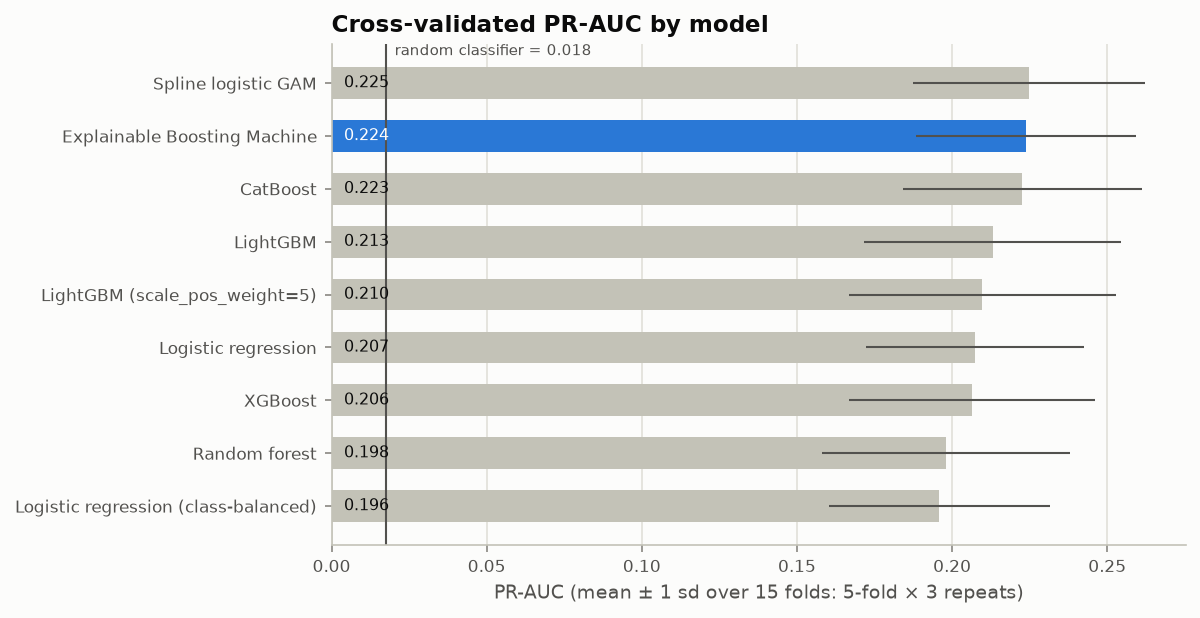

In [9]:
display(Image(FIG / "03_model_comparison.png"))

**What the benchmark tells us**

* **All model families are within one standard deviation of each other** (PR-AUC 0.20–0.23 with fold SD ≈ 0.04). Boosted trees, which can model any interaction, do *not* beat additive models. That is evidence the fraud signal is essentially **additive in the log-odds with non-linear per-feature shapes** — exactly the structure a GAM / EBM assumes.
* **Re-weighting for imbalance does not help.** Class-balanced logistic regression and LightGBM with `scale_pos_weight` score the same or worse on PR-AUC and produce badly mis-calibrated probabilities (higher Brier score). PR-AUC is a ranking metric, and re-weighting doesn't improve the ranking; it only shifts probabilities. We handle imbalance where it matters — at the **decision threshold** — and keep calibrated probabilities. (SMOTE was not used for the same reason, and because synthesising points in a 1:56 problem with heavy noise risks fabricating fraud patterns.)
* **Why the EBM:** it ties for the top PR-AUC and the top importance-weighted (test-like) PR-AUC, is well-calibrated, needs no imputation or encoding, and is a *glass box*: we can show the judges — or a fraud analyst — exactly why each transaction was flagged.

### Assumption check: is "additive + pairwise interactions" enough?
EBM with no interactions (a pure GAM) vs the default EBM (main effects + automatically detected pairwise interactions). LightGBM/XGBoost/CatBoost in the table above stand in for "unrestricted higher-order interactions".

In [10]:
splits = fp.cv_splits(y)
spec_gam = fp.ModelSpec("EBM, main effects only (pure GAM)", lambda: fp.make_ebm(interactions=0))
res_gam = fp.cross_validate(spec_gam, train, splits)
row = fp.summarise_cv(res_gam, y, weights=iw)
ebm_row = cv.loc[cv.model == fp.FINAL_MODEL_NAME].iloc[0]
gbm_best = cv.loc[cv.model.isin(["LightGBM", "XGBoost", "CatBoost"])].sort_values("pr_auc_mean").iloc[-1]
pd.DataFrame([
    {"model": row["model"], "PR-AUC": row["pr_auc_mean"], "sd": row["pr_auc_std"]},
    {"model": "EBM, main + pairwise (chosen)", "PR-AUC": ebm_row.pr_auc_mean, "sd": ebm_row.pr_auc_std},
    {"model": f"best unrestricted GBM ({gbm_best.model})", "PR-AUC": gbm_best.pr_auc_mean, "sd": gbm_best.pr_auc_std},
])

,model,PR-AUC,sd
0,"EBM, main effects only (pure GAM)",0.2197,0.0369
1,"EBM, main + pairwise (chosen)",0.2238,0.0355
2,best unrestricted GBM (CatBoost),0.2226,0.0385


Pairwise interactions add a little; unrestricted interactions add nothing. The additivity assumption is supported by the data.

## 5. Inside the chosen model

An EBM is a **Generalised Additive Model with pairwise interactions (GA²M)**:

$$\text{logit}\,P(\text{fraud}\mid x) = \beta_0 + \sum_j f_j(x_j) + \sum_{(i,j)} f_{ij}(x_i, x_j)$$

Each $f_j$ is learned by cyclic gradient boosting of shallow trees on **one feature at a time** (with a small learning rate and many rounds, so feature order doesn't matter), then bagged over 14 outer bags. The result is a lookup table per feature: the prediction is literally the sum of the table entries, so the model is exactly interpretable.

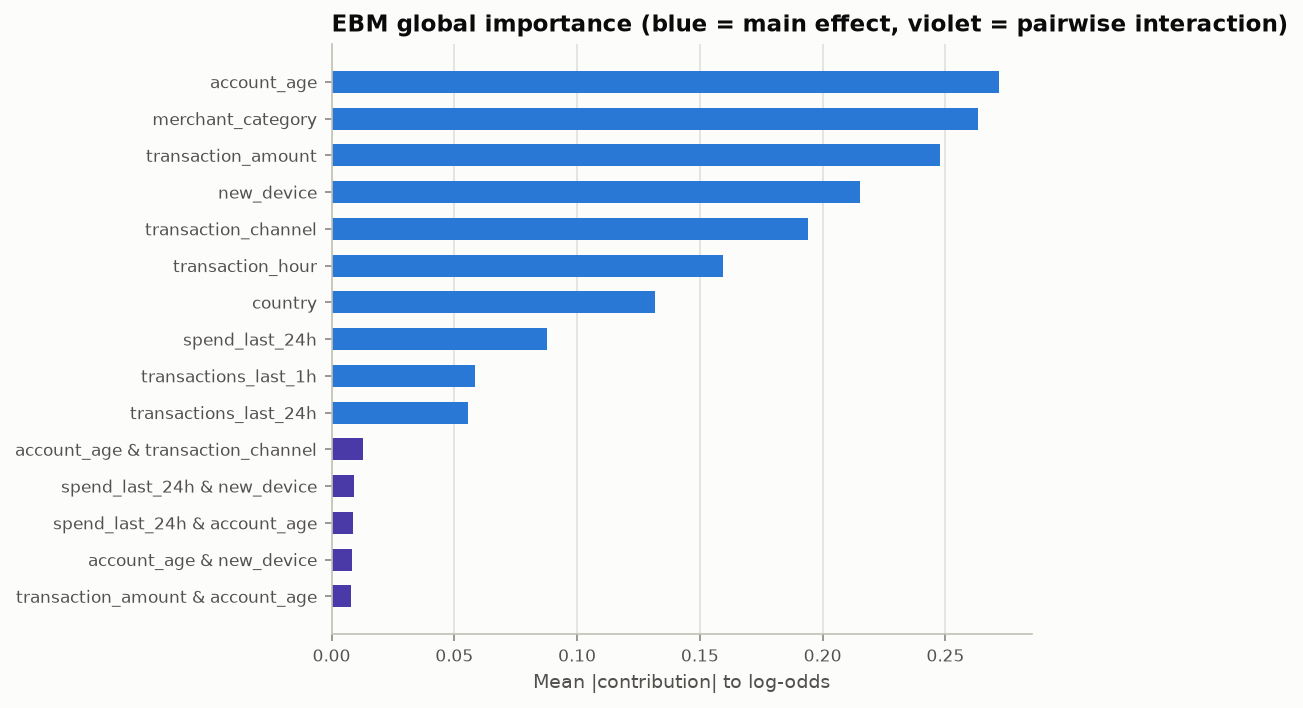

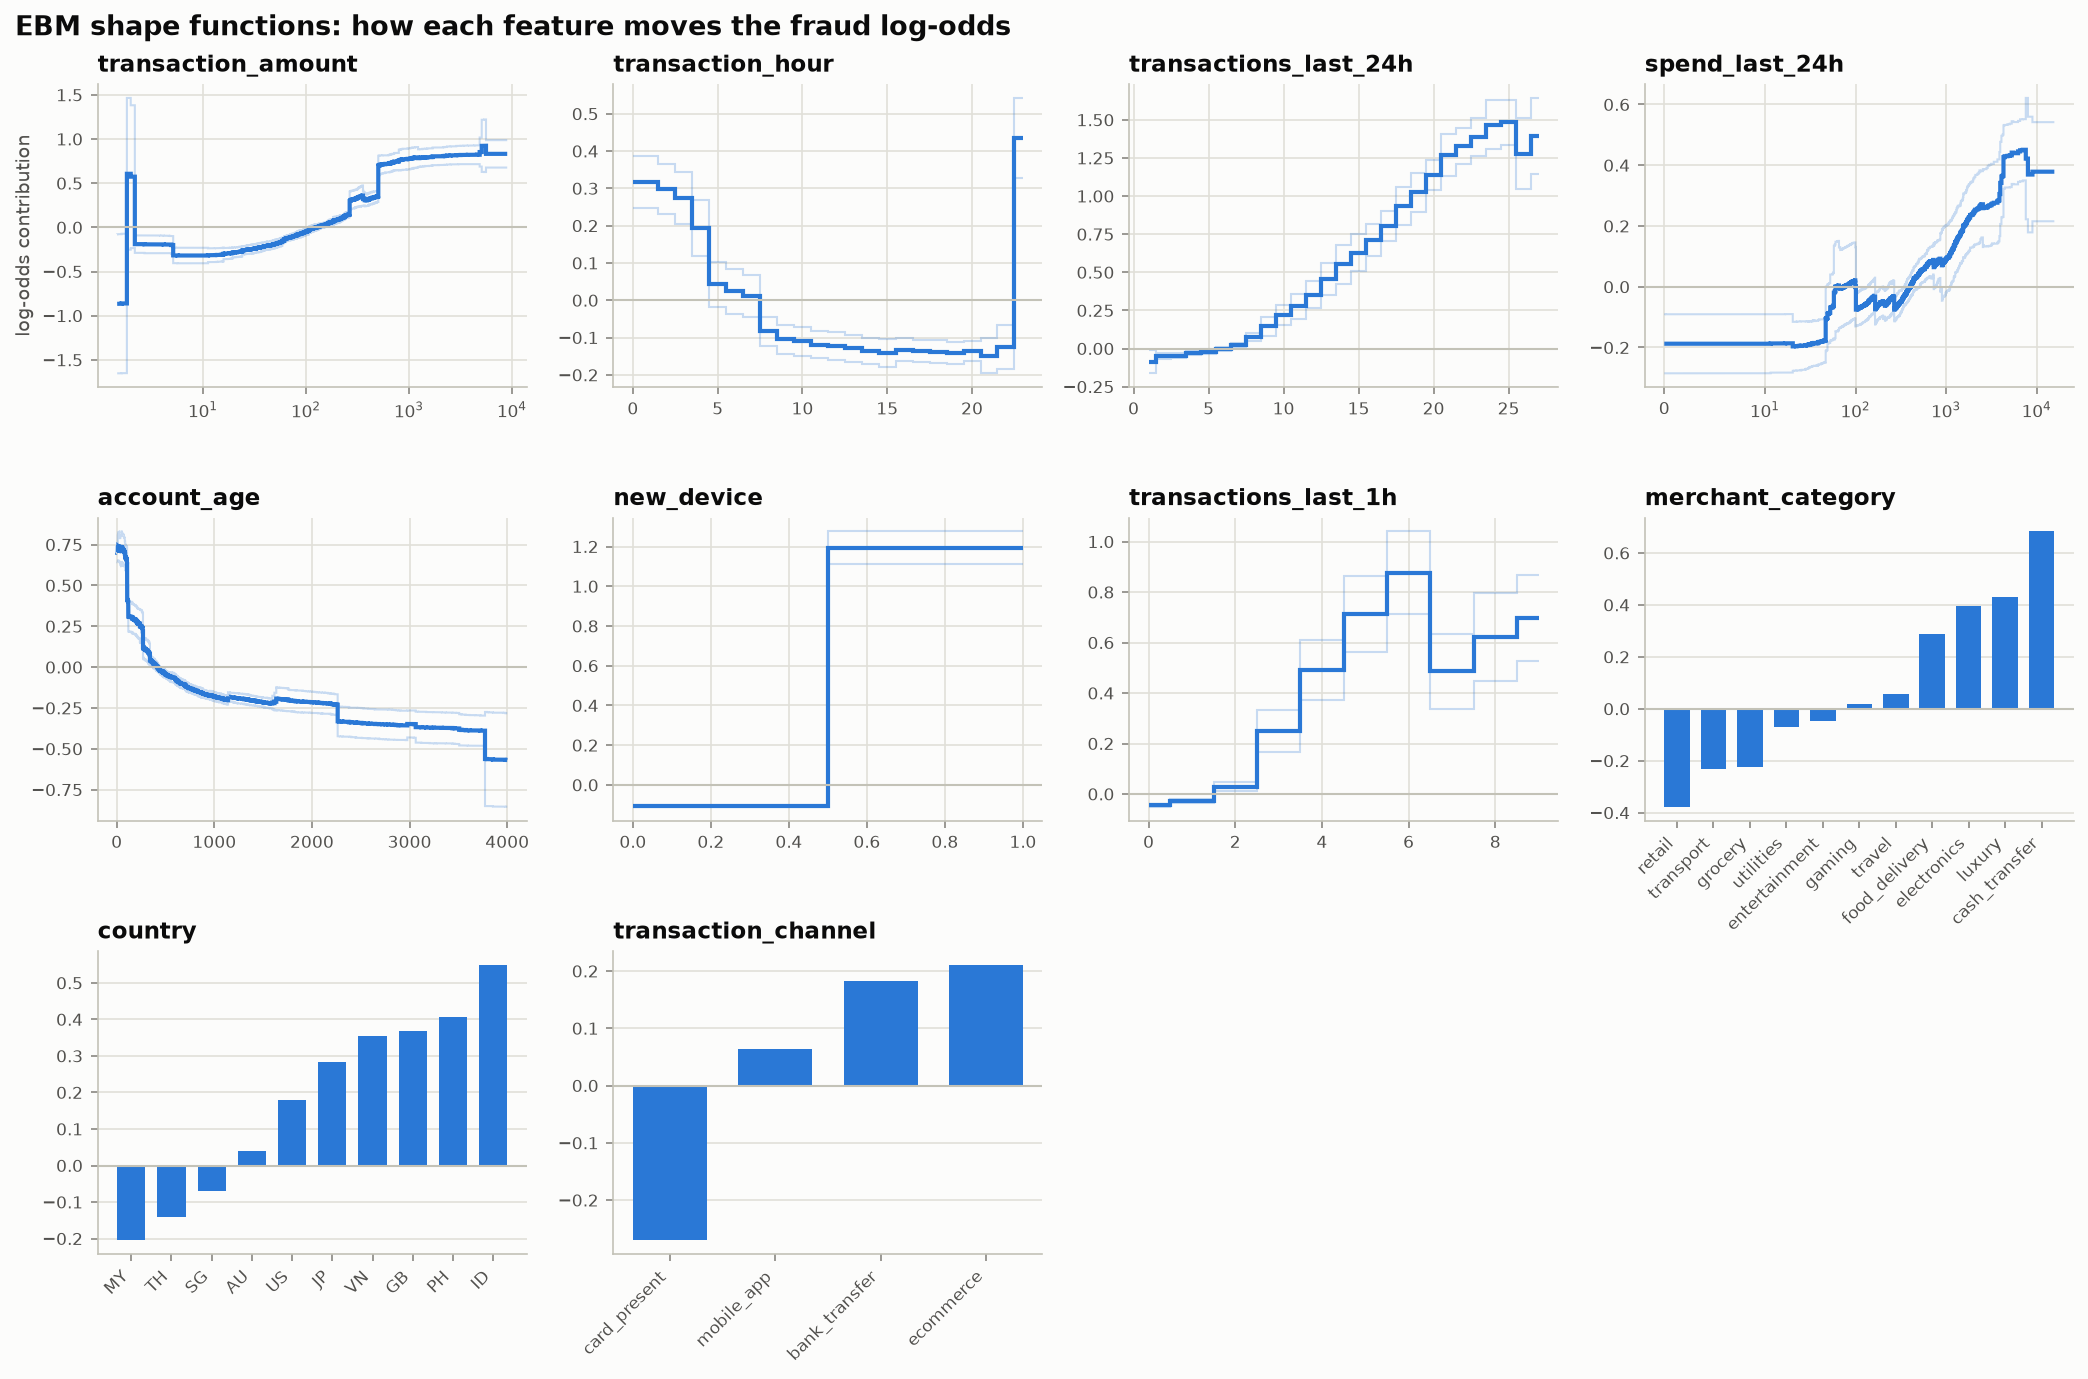

In [11]:
with open(OUT / "ebm_model.pkl", "rb") as f:
    bundle = pickle.load(f)
ebm, THRESHOLD = bundle["model"], bundle["threshold"]
display(Image(FIG / "07_ebm_importance.png"))
display(Image(FIG / "08_ebm_shapes.png"))

**How to read the shape functions** (y-axis = change in log-odds; +0.69 ≈ doubles the odds):

* `new_device` adds ≈ +1.3 log-odds (~3.6× the odds) — the single strongest binary signal.
* `transactions_last_24h` rises steadily beyond ~7 per day; `transactions_last_1h` jumps at ≥3 per hour.
* `account_age` is highest for accounts under ~6 months and falls steadily after.
* `transaction_amount` rises from ~$100 to ~$1k and then **plateaus**. In the raw data, fraud rates *drop* above $3k; the EBM attributes that drop to the other features of those transactions (old accounts, daytime, known devices), not to the amount itself. That is the conditional vs marginal distinction, and it is why the model doesn't over-react to the test set's new large-ticket segment.
* Merchant category (cash transfer, luxury, electronics), channel (e-commerce, bank transfer) and country (ID, PH, GB, VN, JP) behave as the EDA suggested.
* Interactions are small: the largest pair has under a tenth of the importance of the top main effect.

### Explaining an individual decision

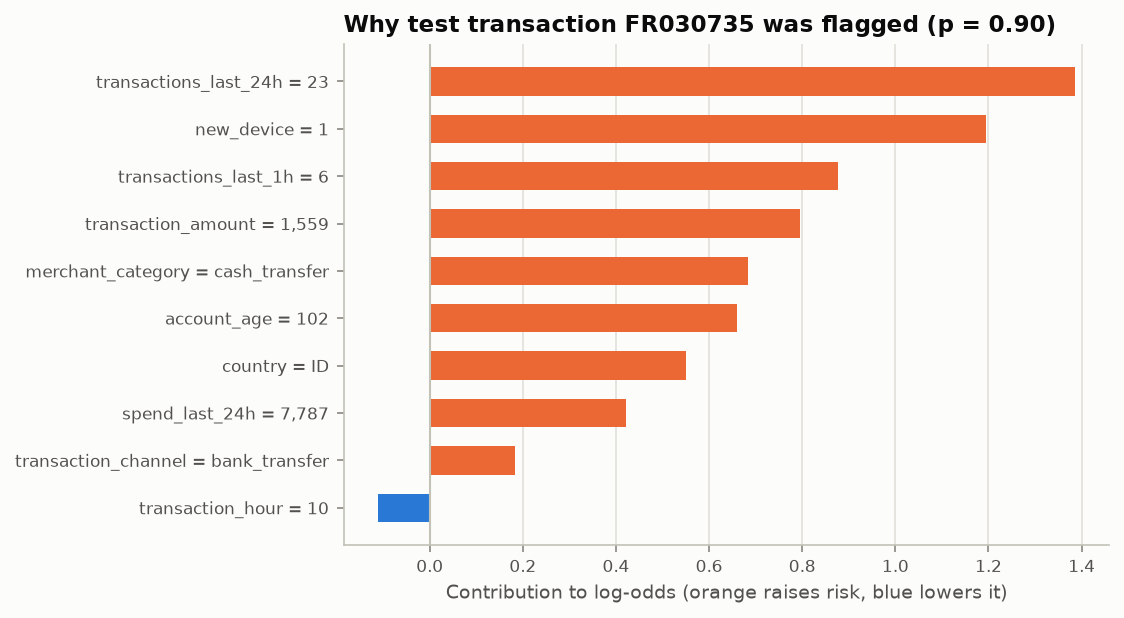

In [12]:
display(Image(FIG / "09_local_explanation.png"))

## 6. Choosing the decision threshold

The rubric scores **F1 and Recall** at our chosen threshold. Their harmonic mean simplifies to an F-beta score:

$$\text{HM}(F_1, R) = \frac{2 F_1 R}{F_1 + R} = \frac{4PR}{3P + R} = F_{\beta}\Big|_{\beta=\sqrt{3}}$$

So we pick the threshold that maximises **F<sub>√3</sub>** on out-of-fold predictions (averaged over the three CV repeats to smooth noise). β = √3 ≈ 1.73 means recall is weighted ~1.7× precision, which also matches the cost asymmetry of fraud.

A useful sanity check: for a calibrated model the F<sub>β</sub>-optimal threshold equals F<sub>β</sub>* / (1 + β²) (Lipton et al., 2014). With F<sub>√3</sub>* ≈ 0.28 that predicts t ≈ 0.07, close to the empirical optimum.

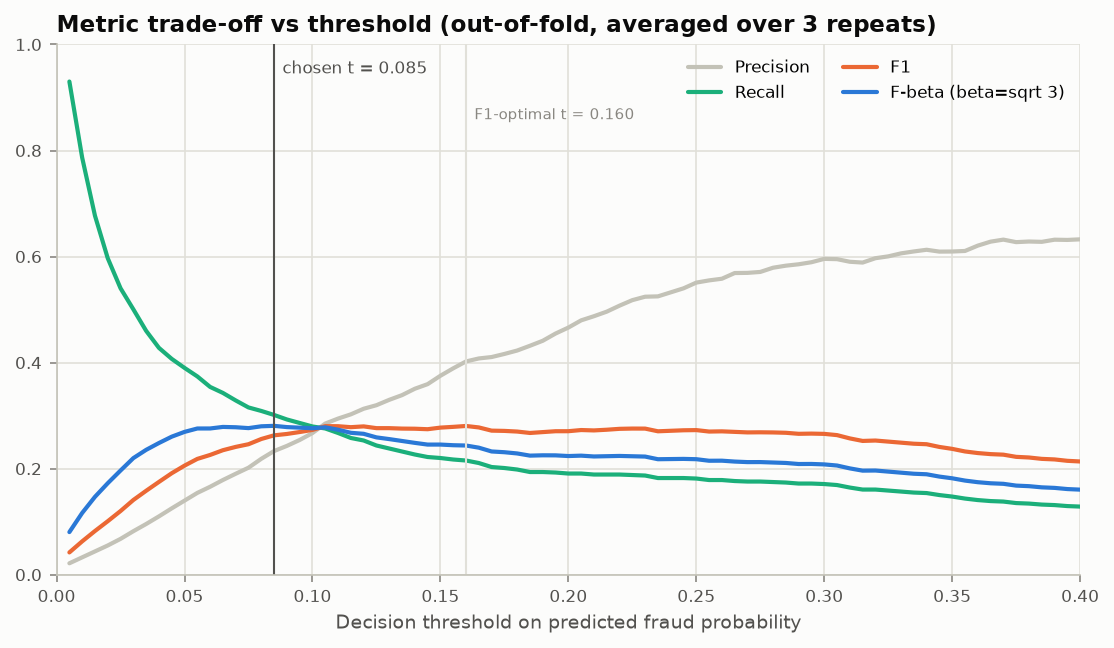

,precision,recall,f1,f2,f_beta,flag_rate
threshold,,,,,,
0.030000,0.082,0.500,0.141,0.248,0.220,0.108
0.050000,0.140,0.390,0.206,0.287,0.269,0.049
0.055000,0.154,0.374,0.218,0.291,0.276,0.043
0.070000,0.190,0.329,0.241,0.287,0.278,0.030
0.085000,0.233,0.301,0.263,0.285,0.281,0.023
0.100000,0.267,0.280,0.273,0.277,0.276,0.019
0.120000,0.313,0.253,0.280,0.263,0.266,0.014
0.160000,0.402,0.215,0.280,0.237,0.244,0.009
0.200000,0.466,0.191,0.271,0.216,0.224,0.007


In [13]:
table = pd.read_csv(OUT / "threshold_table.csv")
display(Image(FIG / "05_threshold_tradeoff.png"))
pts = [0.03, 0.05, 0.055, 0.07, THRESHOLD, 0.10, 0.12, 0.16, 0.20, 0.30, 0.50]
op = table.set_index(table.threshold.round(3)).loc[[round(p, 3) for p in pts],
        ["precision", "recall", "f1", "f2", "f_beta", "flag_rate"]]
op.style.format("{:.3f}").highlight_max(subset=["f1", "f_beta"], color="#cde2fb")

In [14]:
best_fb = table.f_beta.max()
print(f"chosen threshold          t = {THRESHOLD:.3f}")
print(f"theory: F_beta*/(1+beta^2)  = {best_fb / 4:.3f}")
f1row = table.loc[table.f1.idxmax()]
at = table.loc[table.threshold == THRESHOLD].iloc[0]
print(f"at chosen t:   precision {at.precision:.3f}  recall {at.recall:.3f}  F1 {at.f1:.3f}")
print(f"F1-optimal t = {f1row.threshold:.3f}: precision {f1row.precision:.3f}  recall {f1row.recall:.3f}  F1 {f1row.f1:.3f}")
print(f"=> we give up {f1row.f1 - at.f1:.3f} F1 to gain {at.recall - f1row.recall:.3f} recall")

chosen threshold          t = 0.085
theory: F_beta*/(1+beta^2)  = 0.070
at chosen t:   precision 0.233  recall 0.301  F1 0.263
F1-optimal t = 0.160: precision 0.402  recall 0.215  F1 0.280
=> we give up 0.018 F1 to gain 0.086 recall


The F1 curve is almost flat between t ≈ 0.08 and 0.30, while recall falls steeply. Moving from the F1-optimum to our threshold costs very little F1 and buys a large gain in recall. The default 0.5 threshold would catch only ~10% of fraud.

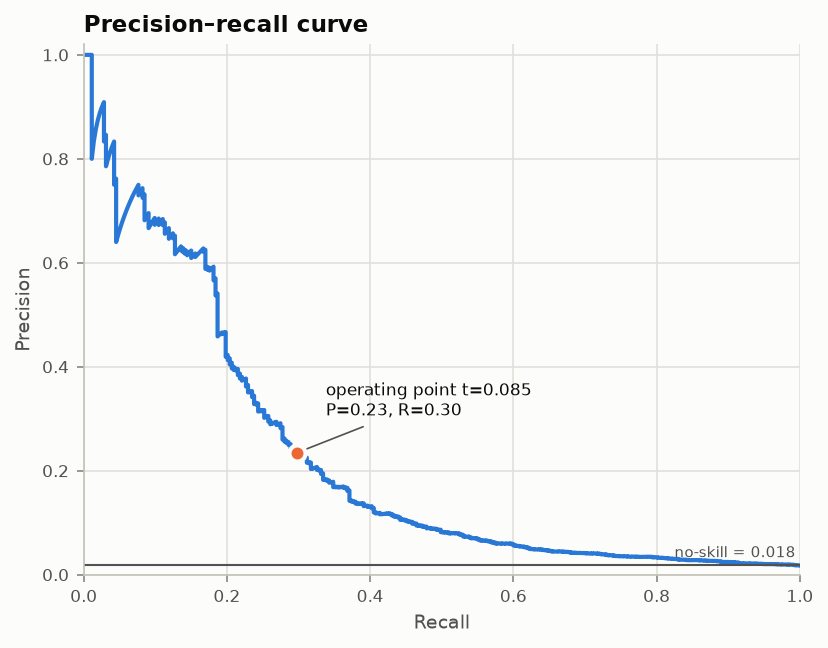

In [15]:
display(Image(FIG / "04_pr_curve.png"))

## 7. Calibration and a forecast for the test set

The threshold rule (and the theory above) assumes the probabilities are **calibrated**: among transactions scored 5%, about 5% should be fraud.

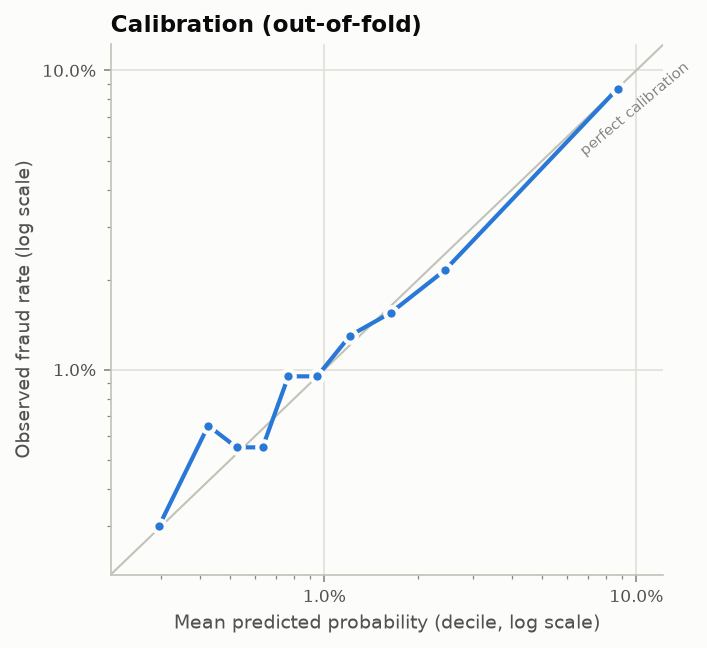

mean OOF probability 0.0176 vs observed fraud rate 0.0176


In [16]:
display(Image(FIG / "06_calibration.png"))
oof = pd.read_csv(OUT / "oof_predictions.csv")
print(f"mean OOF probability {oof.oof_probability.mean():.4f} vs observed fraud rate {y.mean():.4f}")

Calibration is close to the diagonal across the deciles. Under the covariate-shift assumption we can therefore forecast test-set metrics from the predicted probabilities alone (E[TP] = Σ p over flagged rows, etc.):

In [17]:
sub = pd.read_csv(OUT / "submission.csv")
p_test = sub.fraud_probability.to_numpy()
fc = pd.DataFrame([fp.plug_in_metrics(p_test, t) for t in [0.06, 0.07, THRESHOLD, 0.10, 0.12, 0.15]])
print(f"model-implied test fraud rate: {p_test.mean():.2%} (train {y.mean():.3%})")
fc.style.format("{:.3f}")

model-implied test fraud rate: 2.22% (train 1.765%)


,threshold,expected_prevalence,flag_rate,expected_precision,expected_recall,expected_f1,expected_f_beta
0,0.060,0.022,0.056,0.191,0.485,0.274,0.350
1,0.070,0.022,0.048,0.213,0.460,0.292,0.357
2,0.085,0.022,0.039,0.244,0.430,0.311,0.361
3,0.100,0.022,0.033,0.272,0.404,0.325,0.360
4,0.120,0.022,0.027,0.307,0.376,0.338,0.356
5,0.150,0.022,0.021,0.355,0.340,0.347,0.344


The model expects slightly more fraud in the test period (≈2.2%) and better separability there (the drift brought more clear-cut velocity / new-device cases). These are forecasts, valid only if P(fraud | x) is unchanged. If fraudsters changed tactics (concept drift), no model trained on these labels can know it; production monitoring would be needed.

## 8. Assumptions of the model and how we checked them

| # | Assumption | Why it matters | Evidence / mitigation |
|---|---|---|---|
| 1 | **Additivity**: log-odds = sum of per-feature shapes + a few pairwise interactions | the EBM cannot represent 3-way interactions | unrestricted GBMs (LightGBM, XGBoost, CatBoost) do not beat it (§4) |
| 2 | **Independent observations** | CV assumes rows are exchangeable | no customer/card ID is given, so we can't group folds; the velocity features summarise each account's history; the train set shows no ID trend |
| 3 | **Covariate shift only**: P(fraud \| x) is stable between train and test | needed for probabilities and threshold to transfer | adversarial AUC 0.67 shows P(x) shifts; we checked importance-weighted PR-AUC; P(y \| x) cannot be verified without test labels |
| 4 | **Calibrated probabilities** | the threshold is a probability cut-off | reliability curve on the diagonal; mean OOF p = observed rate |
| 5 | **Missing values are uninformative / MCAR** and behave the same in test | the EBM gives missing its own bin | χ² tests: missing rows not significantly more fraudulent; test has 4× more missing, which these bins absorb |
| 6 | **Piecewise-constant shapes, flat extrapolation** | values beyond the training range get the edge bin's score | desirable here: the test's large amounts are not extrapolated into extreme risk |
| 7 | **Labels are correct and complete** | label noise caps achievable PR-AUC | the plateau at ≈0.22 across all models suggests irreducible noise; chargeback lag could mean some frauds are labelled 0 |
| 8 | **Features are available at decision time** | otherwise there is leakage | velocity / spend windows exclude the current transaction (spend < amount in ~20% of rows) |

## 9. Submission file

In [18]:
print(sub.shape)
print(sub.fraud_prediction.value_counts().rename({0: "legit", 1: "fraud"}))
sub.sort_values("fraud_probability", ascending=False).head(10)

(12000, 3)
fraud_prediction
legit    11530
fraud      470
Name: count, dtype: int64


,id,fraud_probability,fraud_prediction
5254,FR030735,0.8968,1
7578,FR021803,0.8520,1
4727,FR025361,0.8133,1
6010,FR020805,0.8128,1
11713,FR025513,0.8086,1
4020,FR029006,0.8004,1
10181,FR029845,0.7670,1
8192,FR027298,0.7595,1
1061,FR021237,0.7581,1
7897,FR028113,0.7490,1
